Jav-Nairobi Feature Engineering

In [1]:
import os
import pandas as pd
import numpy as np
import polars as pl
import geopandas as gpd
pd.set_option('display.max_columns', None)

# Set before importing numpy/pandas/sklearn
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"

In [2]:
import pandas as pd

In [3]:
df3 = pd.read_parquet('/home/dataopske/Desktop/jav/data/processed/wards_full_gdf(with_spatial_temporal_gini).parquet')


In [4]:
# final_df = pd.read_csv('/home/dataopske/Desktop/jav/data/processed/stop_features_complete.csv')
final_df = pd.read_csv('/home/dataopske/Desktop/jav/data/training_data/stop_features_complete.csv')

In [5]:
final_df.shape

(8234, 53)

In [6]:
# Quick join (won't blow up dimensions - it's ward-level aggregation)
final_df1 = final_df.merge(
    df3[['ward', 'subcounty_gini', 'trips_per_1k_pop_per_hour', 'service_rank_overall']].groupby('ward').first(),
    on='ward',
    how='left'
)

In [7]:
final_df1.head(2)

,stop_id,lat,lon,ward,is_existing_stop,nearest_node_degree,is_intersection,road_type,distance_to_major_road,distance_to_nearest_stop,distance_to_2nd_nearest,distance_to_3rd_nearest,avg_spacing_3_nearest,spacing_regularity,stops_within_500m,stops_within_1km,stop_density_1km,pop_density_500m,pop_not_served_nearby,poverty_rate_weighted_pop,route_count_serving,trips_per_day,trips_per_hour_peak,trips_per_hour_offpeak,avg_headway_minutes,service_span_hours,routes_within_500m,avg_speed_daily,avg_speed_peak,avg_speed_offpeak,congestion_pct_daily,congestion_pct_peak,trip_count_daily,trip_count_peak,demand_variability_cv,dominant_congestion_level,ward_pct_access,ward_population,ward_pop_density,ward_poverty_rate,ward_pop_not_served,is_benchmark_ward,ward_service_per_capita,ward_category,distance_to_cbd,coverage_efficiency_nearby,demand_supply_ratio,network_accessibility,equity_score,is_good_stop,pop_within_200m,pop_within_500m,pop_within_1km,subcounty_gini,trips_per_1k_pop_per_hour,service_rank_overall
0,0001RLW,-1.290884,36.828242,Nairobi Central Ward,True,4,True,unclassified,185.404122,173.684507,231.853573,412.893917,272.810666,101.860683,9,57,18.143664,6034.16,0,947.843636,7,14,1.75,0,102.857143,1,7,17.684658,11.666698,20.693638,60.458835,92.241379,543,224.0,0.490429,congested,100.0,18997.268882,6034.16,20.0,0.0,True,148.372205,well_served,1.324902,1.724138,372.666667,0.021459,0.0,1,799.0,5590,27759,0.08231,190.764263,1
1,0002KOJ,-1.281230,36.822596,Nairobi Central Ward,True,3,True,residential,20.568573,5.177885,21.286282,23.097604,16.520590,8.054520,14,66,21.008452,6034.16,0,947.843636,0,0,0.00,0,NaN,0,46,17.684658,11.666698,20.693638,60.458835,92.241379,543,224.0,0.490429,congested,100.0,18997.268882,6034.16,20.0,0.0,True,148.372205,well_served,0.830851,1.492537,5161.000000,0.139091,0.0,1,757.0,5161,23044,0.08231,190.764263,1


In [8]:
final_df1.head(1)

,stop_id,lat,lon,ward,is_existing_stop,nearest_node_degree,is_intersection,road_type,distance_to_major_road,distance_to_nearest_stop,distance_to_2nd_nearest,distance_to_3rd_nearest,avg_spacing_3_nearest,spacing_regularity,stops_within_500m,stops_within_1km,stop_density_1km,pop_density_500m,pop_not_served_nearby,poverty_rate_weighted_pop,route_count_serving,trips_per_day,trips_per_hour_peak,trips_per_hour_offpeak,avg_headway_minutes,service_span_hours,routes_within_500m,avg_speed_daily,avg_speed_peak,avg_speed_offpeak,congestion_pct_daily,congestion_pct_peak,trip_count_daily,trip_count_peak,demand_variability_cv,dominant_congestion_level,ward_pct_access,ward_population,ward_pop_density,ward_poverty_rate,ward_pop_not_served,is_benchmark_ward,ward_service_per_capita,ward_category,distance_to_cbd,coverage_efficiency_nearby,demand_supply_ratio,network_accessibility,equity_score,is_good_stop,pop_within_200m,pop_within_500m,pop_within_1km,subcounty_gini,trips_per_1k_pop_per_hour,service_rank_overall
0,0001RLW,-1.290884,36.828242,Nairobi Central Ward,True,4,True,unclassified,185.404122,173.684507,231.853573,412.893917,272.810666,101.860683,9,57,18.143664,6034.16,0,947.843636,7,14,1.75,0,102.857143,1,7,17.684658,11.666698,20.693638,60.458835,92.241379,543,224.0,0.490429,congested,100.0,18997.268882,6034.16,20.0,0.0,True,148.372205,well_served,1.324902,1.724138,372.666667,0.021459,0.0,1,799.0,5590,27759,0.08231,190.764263,1


In [9]:
print(final_df1.describe())

               lat          lon  nearest_node_degree  distance_to_major_road  \
count  8234.000000  8234.000000          8234.000000             8234.000000   
mean     -1.272163    36.837250             4.672699              522.588103   
std       0.053783     0.078827             1.834025              922.002713   
min      -1.486080    36.620092             1.000000                0.142149   
25%      -1.300309    36.780049             3.000000               40.330036   
50%      -1.274378    36.849303             6.000000              316.324160   
75%      -1.251504    36.895462             6.000000              649.484626   
max      -1.032019    37.081695            10.000000            13418.192504   

       distance_to_nearest_stop  distance_to_2nd_nearest  \
count               8234.000000              8234.000000   
mean                 405.066128               458.789783   
std                  744.879673               742.601810   
min                    0.000000        

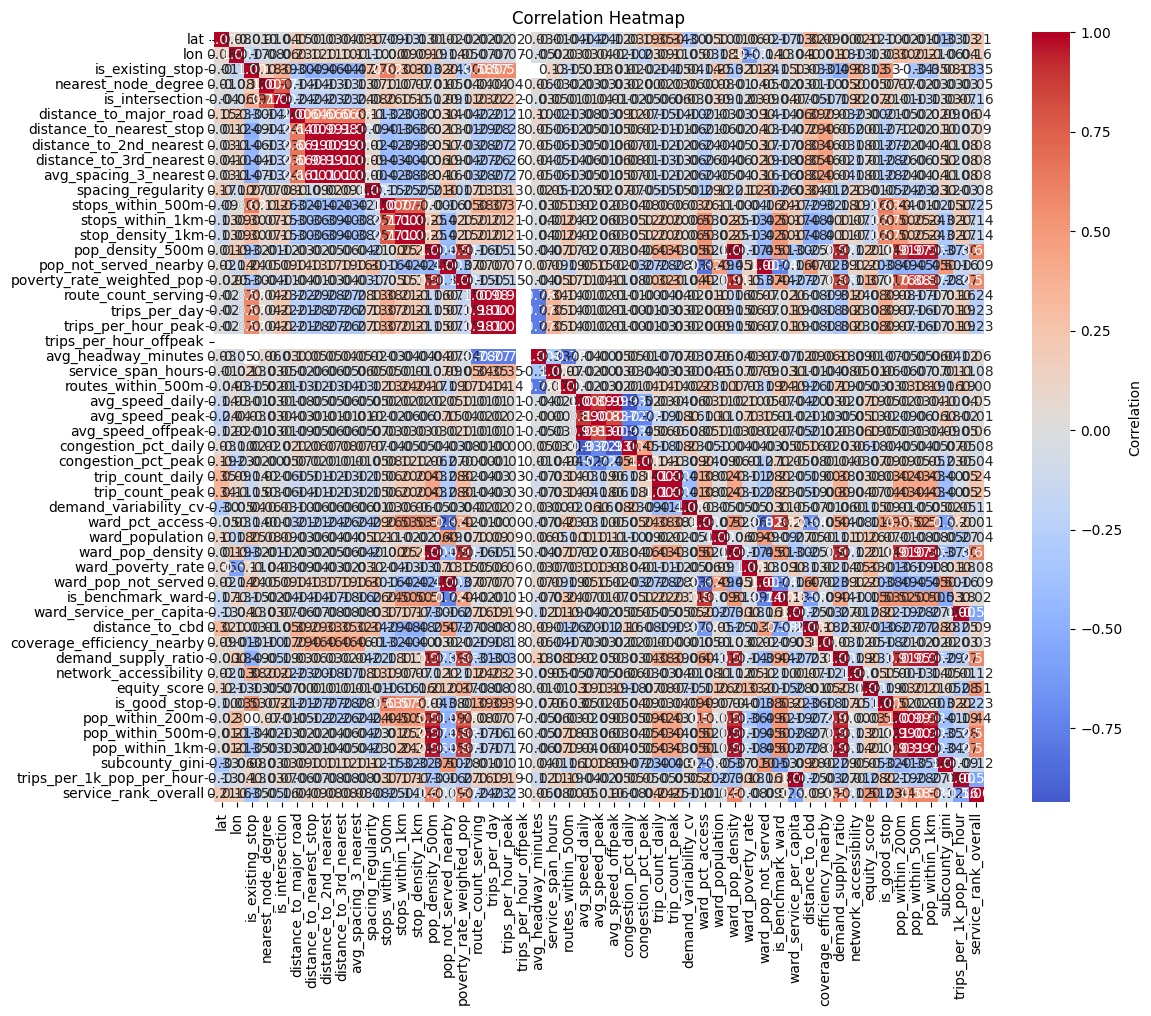

High correlations (|r| > 0.7):
                          var1                     var2      corr
0          nearest_node_degree          is_intersection  0.768856
1              is_intersection      nearest_node_degree  0.768856
2     distance_to_nearest_stop  distance_to_2nd_nearest  0.990939
3     distance_to_nearest_stop  distance_to_3rd_nearest  0.984131
4     distance_to_nearest_stop    avg_spacing_3_nearest  0.995042
..                         ...                      ...       ...
97              pop_within_1km         ward_pop_density  0.961916
98              pop_within_1km      demand_supply_ratio  0.962480
99              pop_within_1km          pop_within_200m  0.933290
100             pop_within_1km          pop_within_500m  0.993355
101  trips_per_1k_pop_per_hour  ward_service_per_capita  1.000000

[102 rows x 3 columns]


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'df' is your DataFrame (replace with your actual df name)
# Compute correlation matrix (Pearson by default; use method='spearman' for rank-based)
corr_matrix = final_df1.corr(numeric_only=True)  # numeric_only=True skips non-numeric cols

# Visualize as heatmap (easy to read)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'label': 'Correlation'})
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Optional: Print high correlations (>0.7 or <-0.7) for quick scan
high_corr = corr_matrix[(abs(corr_matrix) > 0.7) & (corr_matrix != 1.0)].stack().reset_index()
high_corr.columns = ['var1', 'var2', 'corr']
high_corr = high_corr.drop_duplicates()
print("High correlations (|r| > 0.7):")
print(high_corr)

In [11]:
# Prioritize: Keep local (e.g., trips_per_1k_pop_per_hour) > ward-agg (ward_service_per_capita)
# Keep inner (pop_within_500m) > outer (pop_within_1km)
# Keep raw (distance_to_nearest_stop) > derived (avg_spacing_3_nearest)
drops = [
    # Positional (use for graph)
    # 'lat', 'lon',
    
    # Constants/zero-var
    'trips_per_hour_offpeak',
    
    # Ward-agg duplicates (less interpretable)
    'ward_service_per_capita',  # Drop; keep trips_per_1k_pop_per_hour (local equiv)
    'ward_pop_density',         # Drop; keep pop_density_500m (stop-local)
    
    # Nested spatial (keep nearest/inner)
    'distance_to_2nd_nearest', 'distance_to_3rd_nearest', 'avg_spacing_3_nearest', 'spacing_regularity',
    'pop_within_1km', 'pop_within_200m',  # Drop; keep pop_within_500m (balanced local)
    'stop_density_1km',  # Derived; keep stops_within_1km (raw count)
    
    # Flags/derived redundants
    'is_intersection',  # Threshold of nearest_node_degree
    'ward_pop_not_served',  # Ward-agg; pop_not_served_nearby is more local
    'service_rank_overall'  # Global rank; less site-specific
]

# Apply
final_df_clean = final_df1.drop(columns=drops, errors='ignore')  # Ignore if already dropped
print("Dropped cols:", [col for col in drops if col in final_df.columns])
print(f"New shape: {final_df_clean.shape}")

# Quick re-check: Remaining high corrs
num_cols_clean = final_df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = final_df_clean[num_cols_clean].corr()
high_corr = corr_matrix[(abs(corr_matrix) > 0.7) & (corr_matrix != 1.0)].stack().reset_index()
high_corr.columns = ['var1', 'var2', 'corr']
high_corr = high_corr.drop_duplicates()
print("Remaining high corrs (|r| > 0.7):")
print(high_corr)

# New describe (focus on kept cols)
print("\nClean DF Describe (Key Stats):")
print(final_df_clean.describe())

Dropped cols: ['trips_per_hour_offpeak', 'ward_service_per_capita', 'ward_pop_density', 'distance_to_2nd_nearest', 'distance_to_3rd_nearest', 'avg_spacing_3_nearest', 'spacing_regularity', 'pop_within_1km', 'pop_within_200m', 'stop_density_1km', 'is_intersection', 'ward_pop_not_served']
New shape: (8234, 43)
Remaining high corrs (|r| > 0.7):
                         var1                       var2      corr
0           stops_within_500m           stops_within_1km  0.765401
1            stops_within_1km          stops_within_500m  0.765401
2            pop_density_500m  poverty_rate_weighted_pop  0.909363
3            pop_density_500m        demand_supply_ratio  0.924572
4            pop_density_500m            pop_within_500m  0.972898
5       pop_not_served_nearby            ward_pct_access -0.819983
6   poverty_rate_weighted_pop           pop_density_500m  0.909363
7   poverty_rate_weighted_pop        demand_supply_ratio  0.855371
8   poverty_rate_weighted_pop            pop_within_5

In [12]:
final_drops = ['pop_density_500m', 'trips_per_hour_peak', 'service_rank_overall']
final_df_clean = final_df_clean.drop(columns=final_drops, errors='ignore')
print(f"Final shape: {final_df_clean.shape}")

Final shape: (8234, 41)


In [13]:
final_df_clean.head(1)

,stop_id,lat,lon,ward,is_existing_stop,nearest_node_degree,road_type,distance_to_major_road,distance_to_nearest_stop,stops_within_500m,stops_within_1km,pop_not_served_nearby,poverty_rate_weighted_pop,route_count_serving,trips_per_day,avg_headway_minutes,service_span_hours,routes_within_500m,avg_speed_daily,avg_speed_peak,avg_speed_offpeak,congestion_pct_daily,congestion_pct_peak,trip_count_daily,trip_count_peak,demand_variability_cv,dominant_congestion_level,ward_pct_access,ward_population,ward_poverty_rate,is_benchmark_ward,ward_category,distance_to_cbd,coverage_efficiency_nearby,demand_supply_ratio,network_accessibility,equity_score,is_good_stop,pop_within_500m,subcounty_gini,trips_per_1k_pop_per_hour
0,0001RLW,-1.290884,36.828242,Nairobi Central Ward,True,4,unclassified,185.404122,173.684507,9,57,0,947.843636,7,14,102.857143,1,7,17.684658,11.666698,20.693638,60.458835,92.241379,543,224.0,0.490429,congested,100.0,18997.268882,20.0,True,well_served,1.324902,1.724138,372.666667,0.021459,0.0,1,5590,0.08231,190.764263


In [14]:
final_df_clean = final_df_clean.drop(columns='equity_score', errors='ignore')
print(f"Final shape: {final_df_clean.shape}")

Final shape: (8234, 40)


In [15]:
final_df_clean.isna().sum()

stop_id                          0
lat                              0
lon                              0
ward                             0
is_existing_stop                 0
nearest_node_degree              0
road_type                        0
distance_to_major_road           0
distance_to_nearest_stop         0
stops_within_500m                0
stops_within_1km                 0
pop_not_served_nearby            0
poverty_rate_weighted_pop        0
route_count_serving              0
trips_per_day                    0
avg_headway_minutes           3961
service_span_hours               0
routes_within_500m               0
avg_speed_daily                  0
avg_speed_peak                   0
avg_speed_offpeak                0
congestion_pct_daily             0
congestion_pct_peak              0
trip_count_daily                 0
trip_count_peak                  0
demand_variability_cv            0
dominant_congestion_level        0
ward_pct_access                  0
ward_population     

In [16]:
final_df_clean.to_csv('/home/dataopske/Desktop/jav/data/training_data/stop_features_training_data.csv', index=False)

In [17]:
print(final_df_clean.head(5))

   stop_id       lat        lon                  ward  is_existing_stop  \
0  0001RLW -1.290884  36.828242  Nairobi Central Ward              True   
1  0002KOJ -1.281230  36.822596  Nairobi Central Ward              True   
2  0003NGR -1.274395  36.823806       Ngara Ward Ward              True   
3  0004ODN -1.282769  36.825032  Nairobi Central Ward              True   
4  0005AMB -1.285963  36.826048  Nairobi Central Ward              True   

   nearest_node_degree       road_type  distance_to_major_road  \
0                    4    unclassified              185.404122   
1                    3     residential               20.568573   
2                    3         primary               58.275689   
3                    3        tertiary               67.183239   
4                    4  secondary_link               60.725155   

   distance_to_nearest_stop  stops_within_500m  stops_within_1km  \
0                173.684507                  9                57   
1               

In [18]:
final_df_clean.shape

(8234, 40)